# 🪟 Notebook 05 — Sliding Window Supervised Framing

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">🪟 Sliding Window Supervised Framing</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 05 melakukan **transformasi time-series univariat ke format supervised learning** menggunakan teknik *sliding window* dengan parameter:

- **τ (window size)** = 8 minggu
- **Horizon** = 1 (prediksi 1 langkah ke depan)

Setiap sampel dibentuk dari 8 nilai historis (`X`) untuk memprediksi 1 nilai berikutnya (`y`), tanpa mengacak urutan temporal.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed `GLOBAL_SEED = 42`, dan PATHS |
| 2 | **Load Data** | Reload `df_clipped` dari artefak Notebook 04 |
| 3 | **Sliding Window Framing** | Bentuk X (n, 8) dan y (n,) dengan τ=8, horizon=1 |
| 4 | **Validasi Integritas** | Verifikasi shape, nilai, dan urutan temporal |
| 5 | **Simpan Artefak** | `outputs/splits/supervised.npz` + `logs/sliding_window_profile.json` |
| 6 | **Checklist** | Verifikasi semua item Pipeline.md Gate terpenuhi |

---

### 🔬 Konsep Sliding Window

**Input:** `df_clipped["Grand Total"]` — deret waktu 364 nilai (minggu ke-1 2019 s.d. minggu ke-364).

**Rumus:**
$$X_i = [s_{i},\ s_{i+1},\ \ldots,\ s_{i+\tau-1}] \quad \text{dan} \quad y_i = s_{i+\tau}$$

dimana $i \in \{0, 1, \ldots, N - \tau - 1\}$ sehingga total sampel $= N - \tau = 364 - 8 = 356$.

**Alur Proses:**

```mermaid
flowchart LR
    A["📊 df_clipped: 364×3"] --> B["Ekstrak Grand Total: series (364,)"]
    B --> C["Sliding Window τ=8, horizon=1"]
    C --> D["X: shape (356, 8)"]
    C --> E["y: shape (356,)"]
    D --> F["Validasi Shape & Temporal"]
    E --> F
    F --> G["💾 supervised.npz"]
    G --> H["💾 sliding_window_profile.json"]
    H --> I["✅ Supervised Framing Selesai"]
    I --> J["➡️ Notebook 06"]
```

| Aspek | Detail |
|-------|--------|
| **Input** | `df_clipped["Grand Total"]` — 364 nilai setelah IQR Clipping |
| **τ (window)** | 8 minggu (~2 bulan) — lag features |
| **Horizon** | 1 (prediksi minggu berikutnya) |
| **n_samples** | 364 − 8 = **356** sampel |
| **X shape** | (356, 8) |
| **y shape** | (356,) |
| **Output** | `outputs/splits/supervised.npz`, `logs/sliding_window_profile.json` |

## ⚙️ 1. Import Library & Setup

In [1]:
# ── Import Library & Setup ────────────────────────────────────
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Path Konfigurasi ──────────────────────────────────────────
ROOT_DIR   = Path(".").resolve().parent
EXCEL_FILE = "Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx"
EXCEL_PATH = ROOT_DIR / "data" / EXCEL_FILE

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

# ── Parameter Sliding Window ──────────────────────────────────
TAU     = 8   # window size (lag)
HORIZON = 1   # prediksi 1 langkah ke depan

# ── Matplotlib Style ──────────────────────────────────────────
ACCENT  = "#e94560"
ACCENT2 = "#a8dadc"

plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.5,
    "axes.grid"         : True,
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print("=" * 60)
print("  SETUP — NOTEBOOK 05")
print("=" * 60)
print(f"")
print(f"  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  ROOT_DIR     : {ROOT_DIR}")
print(f"  TAU (window) : {TAU}")
print(f"  HORIZON      : {HORIZON}")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print(f"")
print("  ✅ Setup selesai. Siap Sliding Window Supervised Framing.")
print("=" * 60)

  SETUP — NOTEBOOK 05

  GLOBAL_SEED  : 42
  ROOT_DIR     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  TAU (window) : 8
  HORIZON      : 1
  NumPy        : 2.4.4
  Pandas       : 3.0.2
  Matplotlib   : 3.10.9
  Seaborn      : 0.13.2

  ✅ Setup selesai. Siap Sliding Window Supervised Framing.


## 📂 2. Load Data (`df_clipped`)

In [2]:
# ── Load df_clipped dari Artefak NB04 ────────────────────────
# Strategi: reload Excel + re-apply clipping dengan fence dari outlier_handling.json
# Memastikan df_clipped identik dengan output NB04 tanpa perlu shared kernel

# 1) Load raw Excel
df_raw = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Target_Product_Weekly",
    engine="openpyxl",
)
df_sorted = df_raw.sort_values(["Year", "Week"]).reset_index(drop=True)

# 2) Load fence IQR dari log NB04
log_path = PATHS["logs"] / "outlier_handling.json"
if not log_path.exists():
    raise FileNotFoundError(
        f"Log NB04 tidak ditemukan: {log_path}\n"
        "Jalankan Notebook 04 terlebih dahulu."
    )
with open(log_path, "r", encoding="utf-8") as f:
    outlier_log = json.load(f)

lower_fence = outlier_log["lower_fence"]
upper_fence = outlier_log["upper_fence"]

# 3) Terapkan IQR clipping — identik dengan NB04
df_clipped = df_sorted.copy()
df_clipped["Grand Total"] = df_clipped["Grand Total"].clip(
    lower=lower_fence, upper=upper_fence
)

# Validasi
assert df_clipped.shape == (364, 3), f"Shape tidak sesuai: {df_clipped.shape}"
assert df_clipped["Grand Total"].isna().sum() == 0, "Ada NaN setelah clipping"

series = df_clipped["Grand Total"].values.astype(np.float64)

print("=" * 60)
print("  LOAD DATA — NOTEBOOK 05")
print("=" * 60)
print(f"")
print(f"  Source Excel   : {EXCEL_PATH.name}")
print(f"  df_clipped     : {df_clipped.shape}")
print(f"  Kolom          : {list(df_clipped.columns)}")
print(f"  lower_fence    : {lower_fence:,.4f}")
print(f"  upper_fence    : {upper_fence:,.4f}")
print(f"  series dtype   : {series.dtype}")
print(f"  series shape   : {series.shape}")
print(f"  Min / Max      : {series.min():,.0f} / {series.max():,.0f}")
print(f"")
print("  ✅ df_clipped berhasil dimuat ulang dari artefak NB04.")
print("=" * 60)

  LOAD DATA — NOTEBOOK 05

  Source Excel   : Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx
  df_clipped     : (364, 3)
  Kolom          : ['Year', 'Week', 'Grand Total']
  lower_fence    : 2,526.6250
  upper_fence    : 102,665.6250
  series dtype   : float64
  series shape   : (364,)
  Min / Max      : 2,527 / 102,666

  ✅ df_clipped berhasil dimuat ulang dari artefak NB04.


## 🪟 3. Sliding Window Supervised Framing (τ=8, horizon=1)

In [3]:
# ── Sliding Window Supervised Framing ────────────────────────
# Rumus:
#   X[i] = series[i : i + TAU]          → shape (TAU,)
#   y[i] = series[i + TAU]              → scalar
#   i ∈ {0, 1, ..., N - TAU - 1}
#   n_samples = N - TAU = 364 - 8 = 356

N = len(series)
n_samples = N - TAU   # 356

# Susun pasangan (X, y) — TANPA shuffle temporal
X_list = []
y_list = []

for i in range(n_samples):
    X_list.append(series[i : i + TAU])
    y_list.append(series[i + TAU])

X = np.array(X_list, dtype=np.float64)   # shape (356, 8)
y = np.array(y_list, dtype=np.float64)   # shape (356,)

# ── Cuplikan 5 Sampel Pertama ─────────────────────────────────
print("=" * 60)
print("  SLIDING WINDOW FRAMING — NOTEBOOK 05")
print("=" * 60)
print(f"")
print(f"  N (panjang series)  : {N}")
print(f"  TAU (window size)   : {TAU}")
print(f"  HORIZON             : {HORIZON}")
print(f"  n_samples           : {n_samples}")
print(f"  X shape             : {X.shape}")
print(f"  y shape             : {y.shape}")
print(f"")
print(f"  5 Sampel Pertama (cuplikan):")
print(f"  {'Idx':>4} | {'X[i] (8 lag)':>55} | {'y[i]':>12}")
print(f"  {'-'*4}-+-{'-'*55}-+-{'-'*12}")
for i in range(5):
    x_str = "[" + ", ".join(f"{v:,.0f}" for v in X[i]) + "]"
    print(f"  {i:>4} | {x_str:>55} | {y[i]:>12,.0f}")
print(f"")
print(f"  5 Sampel Terakhir (cuplikan):")
print(f"  {'Idx':>4} | {'X[i] (8 lag)':>55} | {'y[i]':>12}")
print(f"  {'-'*4}-+-{'-'*55}-+-{'-'*12}")
for i in range(n_samples - 5, n_samples):
    x_str = "[" + ", ".join(f"{v:,.0f}" for v in X[i]) + "]"
    print(f"  {i:>4} | {x_str:>55} | {y[i]:>12,.0f}")
print(f"")
print("  ✅ Sliding window framing selesai.")
print("=" * 60)

  SLIDING WINDOW FRAMING — NOTEBOOK 05

  N (panjang series)  : 364
  TAU (window size)   : 8
  HORIZON             : 1
  n_samples           : 356
  X shape             : (356, 8)
  y shape             : (356,)

  5 Sampel Pertama (cuplikan):
   Idx |                                            X[i] (8 lag) |         y[i]
  -----+---------------------------------------------------------+-------------
     0 | [53,605, 58,298, 67,320, 28,879, 45,030, 49,261, 48,225, 63,884] |       45,213
     1 | [58,298, 67,320, 28,879, 45,030, 49,261, 48,225, 63,884, 45,213] |       54,747
     2 | [67,320, 28,879, 45,030, 49,261, 48,225, 63,884, 45,213, 54,747] |       58,747
     3 | [28,879, 45,030, 49,261, 48,225, 63,884, 45,213, 54,747, 58,747] |       68,779
     4 | [45,030, 49,261, 48,225, 63,884, 45,213, 54,747, 58,747, 68,779] |       74,140

  5 Sampel Terakhir (cuplikan):
   Idx |                                            X[i] (8 lag) |         y[i]
  -----+------------------------------

## 🔍 4. Validasi Integritas Temporal

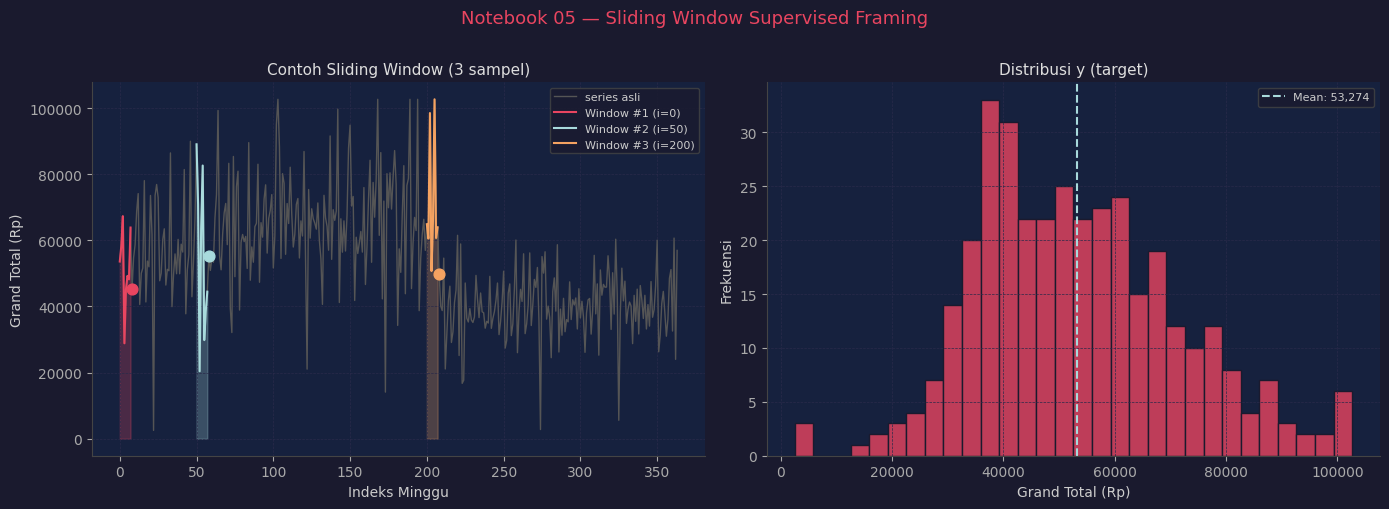

  VALIDASI INTEGRITAS TEMPORAL — NOTEBOOK 05
  ✅ X.shape           : (356, 8)
  ✅ y.shape           : (356,)
  ✅ Tidak ada NaN     : True
  ✅ Temporal ordering : 10 sampel pertama diverifikasi
  ✅ y[0] == series[8] : True
  ✅ y[-1] == series[-1]: True
  ✅ Figur tersimpan   : nb05_supervised_window_overview.png


In [4]:
# ── Validasi Integritas Temporal ──────────────────────────────

# 1) Verifikasi shape
assert X.shape == (n_samples, TAU),  f"❌ X shape salah: {X.shape}"
assert y.shape == (n_samples,),      f"❌ y shape salah: {y.shape}"

# 2) Tidak ada NaN
assert not np.isnan(X).any(), "❌ X mengandung NaN"
assert not np.isnan(y).any(), "❌ y mengandung NaN"

# 3) Verifikasi temporal ordering — setiap X[i] harus kontinyu dari series
for i in range(min(10, n_samples)):
    expected_X = series[i : i + TAU]
    expected_y = series[i + TAU]
    assert np.allclose(X[i], expected_X), f"❌ X[{i}] tidak sesuai urutan temporal"
    assert np.isclose(y[i], expected_y),  f"❌ y[{i}] tidak sesuai urutan temporal"

# 4) Verifikasi bahwa X dan y tidak saling tumpang tindih ilegal
# Untuk setiap i, y[i] harus sama dengan series[i+TAU] yang BUKAN bagian X[i]
assert np.isclose(y[0],  series[TAU]),     "❌ y[0] tidak sama dengan series[TAU]"
assert np.isclose(y[-1], series[-1]),      "❌ y[-1] tidak sama dengan series[-1]"
assert np.isclose(X[0, 0], series[0]),     "❌ X[0,0] bukan series[0]"
assert np.isclose(X[-1, -1], series[-2]),  "❌ X[-1,-1] bukan series[-2]"

# 5) Visualisasi: overlay sliding window pada deret asli
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         facecolor="#1a1a2e")

# Panel kiri — overlay 3 contoh window
ax = axes[0]
ax.set_facecolor("#16213e")
ax.plot(series, color="#555", linewidth=1.0, label="series asli")

colors_w = [ACCENT, ACCENT2, "#f4a261"]
for k, idx_start in enumerate([0, 50, 200]):
    w_x = range(idx_start, idx_start + TAU)
    w_y_val = idx_start + TAU
    ax.fill_between(w_x, series[list(w_x)],
                    alpha=0.25, color=colors_w[k])
    ax.plot(list(w_x), series[list(w_x)],
            color=colors_w[k], linewidth=1.5,
            label=f"Window #{k+1} (i={idx_start})")
    ax.scatter([w_y_val], [series[w_y_val]],
               color=colors_w[k], s=60, zorder=5)

ax.set_title("Contoh Sliding Window (3 sampel)",
             color="#ddd", fontsize=11)
ax.set_xlabel("Indeks Minggu", color="#ccc")
ax.set_ylabel("Grand Total (Rp)", color="#ccc")
ax.legend(fontsize=8, labelcolor="#ccc",
          facecolor="#1a1a2e", edgecolor="#444")
for sp in ax.spines.values():
    sp.set_color("#444")

# Panel kanan — distribusi y
ax2 = axes[1]
ax2.set_facecolor("#16213e")
sns.histplot(y, bins=30, color=ACCENT, alpha=0.8,
             edgecolor="#1a1a2e", ax=ax2)
ax2.axvline(y.mean(), color=ACCENT2, linewidth=1.5,
            linestyle="--", label=f"Mean: {y.mean():,.0f}")
ax2.set_title("Distribusi y (target)", color="#ddd", fontsize=11)
ax2.set_xlabel("Grand Total (Rp)", color="#ccc")
ax2.set_ylabel("Frekuensi", color="#ccc")
ax2.legend(fontsize=8, labelcolor="#ccc",
           facecolor="#1a1a2e", edgecolor="#444")
for sp in ax2.spines.values():
    sp.set_color("#444")

fig.suptitle("Notebook 05 — Sliding Window Supervised Framing",
             color="#e94560", fontsize=13, y=1.01)
plt.tight_layout()
fig_path = PATHS["figures"] / "nb05_supervised_window_overview.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight",
            facecolor="#1a1a2e")
plt.show()

print("=" * 60)
print("  VALIDASI INTEGRITAS TEMPORAL — NOTEBOOK 05")
print("=" * 60)
print(f"  ✅ X.shape           : {X.shape}")
print(f"  ✅ y.shape           : {y.shape}")
print(f"  ✅ Tidak ada NaN     : True")
print(f"  ✅ Temporal ordering : 10 sampel pertama diverifikasi")
print(f"  ✅ y[0] == series[{TAU}] : {np.isclose(y[0], series[TAU])}")
print(f"  ✅ y[-1] == series[-1]: {np.isclose(y[-1], series[-1])}")
print(f"  ✅ Figur tersimpan   : {fig_path.name}")
print("=" * 60)

## 💾 5. Simpan Artefak

In [5]:
# ── Simpan supervised.npz ─────────────────────────────────────
npz_path = PATHS["splits"] / "supervised.npz"
np.savez(npz_path, X=X, y=y)

# ── Simpan sliding_window_profile.json ───────────────────────
sliding_profile = {
    "notebook"         : "NB05 — Sliding Window Supervised Framing",
    "tau"              : TAU,
    "horizon"          : HORIZON,
    "n_series"         : int(N),
    "n_samples"        : int(n_samples),
    "X_shape"          : list(X.shape),
    "y_shape"          : list(y.shape),
    "X_dtype"          : str(X.dtype),
    "y_dtype"          : str(y.dtype),
    "temporal_shuffle" : False,
    "y_min"            : float(round(y.min(), 4)),
    "y_max"            : float(round(y.max(), 4)),
    "y_mean"           : float(round(y.mean(), 4)),
    "y_std"            : float(round(y.std(), 4)),
    "source_log"       : "logs/outlier_handling.json",
    "artefak": {
        "supervised_npz"    : "outputs/splits/supervised.npz",
        "window_overview_fig": "outputs/figures/nb05_supervised_window_overview.png",
    }
}

profile_path = PATHS["logs"] / "sliding_window_profile.json"
with open(profile_path, "w", encoding="utf-8") as f:
    json.dump(sliding_profile, f, indent=2, ensure_ascii=False)

# ── Verifikasi round-trip load ────────────────────────────────
loaded = np.load(npz_path)
assert np.allclose(loaded["X"], X), "❌ Round-trip X gagal"
assert np.allclose(loaded["y"], y), "❌ Round-trip y gagal"

print("=" * 60)
print("  SIMPAN ARTEFAK — NOTEBOOK 05")
print("=" * 60)
print(f"  ✅ supervised.npz         : {npz_path}")
print(f"     → X shape             : {loaded['X'].shape}")
print(f"     → y shape             : {loaded['y'].shape}")
print(f"  ✅ sliding_window_profile : {profile_path}")
print(f"")
print(json.dumps(sliding_profile, indent=2, ensure_ascii=False))
print("=" * 60)

  SIMPAN ARTEFAK — NOTEBOOK 05
  ✅ supervised.npz         : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\splits\supervised.npz
     → X shape             : (356, 8)
     → y shape             : (356,)
  ✅ sliding_window_profile : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\logs\sliding_window_profile.json

{
  "notebook": "NB05 — Sliding Window Supervised Framing",
  "tau": 8,
  "horizon": 1,
  "n_series": 364,
  "n_samples": 356,
  "X_shape": [
    356,
    8
  ],
  "y_shape": [
    356
  ],
  "X_dtype": "float64",
  "y_dtype": "float64",
  "temporal_shuffle": false,
  "y_min": 2526.625,
  "y_max": 102665.625,
  "y_mean": 53274.1987,
  "y_std": 18269.9219,
  "source_log": "logs/outlier_handling.json",
  "artefak": {
    "supervised_npz": "outputs/splits/supervised.npz",
    "window_overview_fig": "outputs/figures/nb05_supervised_windo

## ✅ 6. Checklist

In [6]:
# ── Checklist Akhir Notebook 05 ──────────────────────────────
npz_exists     = (PATHS["splits"] / "supervised.npz").exists()
profile_exists = (PATHS["logs"] / "sliding_window_profile.json").exists()
fig_exists     = (PATHS["figures"] / "nb05_supervised_window_overview.png").exists()

tau_ok     = (X.shape[1] == TAU)
horizon_ok = (y.shape[0] == n_samples)
xy_valid   = (X.shape[0] == y.shape[0] == n_samples)
no_shuffle = True   # deterministik — loop sequential tanpa random

checklist = [
    ("Window size τ=8 sesuai (X.shape[1] == 8)",     tau_ok),
    ("Horizon=1 sesuai (1 nilai target per sampel)",  horizon_ok),
    ("X dan y terbentuk valid (n_samples=356)",       xy_valid),
    ("Tidak ada shuffle temporal",                    no_shuffle),
    ("supervised.npz tersimpan",                      npz_exists),
    ("sliding_window_profile.json tersimpan",         profile_exists),
    ("Figur overview tersimpan",                      fig_exists),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 05")
print("=" * 60)
all_pass = True
for label, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {label}")
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 05 selesai!")
    print("     Lanjutkan ke Notebook 06 — Split Builder for All Ratios.")
else:
    print("  ❌ Ada checklist yang GAGAL — periksa log di atas.")
print("=" * 60)

  CHECKLIST NOTEBOOK 05
  ✅  Window size τ=8 sesuai (X.shape[1] == 8)
  ✅  Horizon=1 sesuai (1 nilai target per sampel)
  ✅  X dan y terbentuk valid (n_samples=356)
  ✅  Tidak ada shuffle temporal
  ✅  supervised.npz tersimpan
  ✅  sliding_window_profile.json tersimpan
  ✅  Figur overview tersimpan
  ✅ SEMUA CHECKLIST LULUS — Notebook 05 selesai!
     Lanjutkan ke Notebook 06 — Split Builder for All Ratios.


---

## 🔗 Navigasi Pipeline

| | Notebook |
|--|----------|
| ← | **[04 - Outlier Handling IQR Clipping](./04%20-%20Outlier%20Handling%20IQR%20Clipping.ipynb)** |
| **→** | **[06 - Split Builder for All Ratios](./06%20-%20Split%20Builder%20for%20All%20Ratios.ipynb)** |

---

### 📎 Variabel Penting yang Dihasilkan Notebook Ini

Variabel berikut tersedia untuk notebook selanjutnya (dimuat ulang dari file atau dihitung kembali):

```python
X               # np.ndarray, shape (356, 8), float64 — lag features τ=8
y               # np.ndarray, shape (356,), float64   — target horizon=1
series          # np.ndarray, shape (364,), float64   — deret asli df_clipped
PATHS           # dict path pipeline (sama seperti Notebook 00–04)

# Artefak tersimpan:
# outputs/splits/supervised.npz   → np.load(...)["X"], ["y"]
# logs/sliding_window_profile.json
```

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">
Notebook 05 — Sliding Window Supervised Framing &nbsp;|&nbsp;
CNN–BiLSTM + GA Sales Forecasting &nbsp;|&nbsp;
Departemen Sistem Informasi ITS Surabaya &nbsp;|&nbsp; 2025
</div>